<a href="https://colab.research.google.com/github/HM-Mahibullah/googlecolab/blob/main/image_classification_apple_tomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon Jun  1 06:12:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Create the hidden .kaggle directory in the root home folder
!mkdir -p ~/.kaggle

# Copy your uploaded kaggle.json API key token into that directory
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d samuelcortinhas/apples-or-tomatoes-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification
License(s): CC0-1.0
100% 2.33M/2.33M [00:00<00:00, 214MB/s]



In [ ]:
!unzip -q apples-or-tomatoes-image-classification.zip

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, Input

In [ ]:
import tensorflow as tf
from tensorflow import keras

# ১. ট্রেনিং ডেটাসেট লোড করা
train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

# ২. ভ্যালিডেশন বা টেস্ট ডেটাসেট লোড করা
validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


In [ ]:
# সিকুয়েনশিয়াল মডেল অবজেক্ট তৈরি করা
model = Sequential()

# --- ১ম কনভোলিউশন ব্লক ---
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# --- ২য় কনভোলিউশন ব্লক ---
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# --- ৩য় কনভোলিউশন ব্লক ---
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# --- ক্লাসিফিকেশন হেড (Fully Connected Layers) ---
model.add(Flatten())

# ১ম ডেন্স লেয়ার + ১০% ড্রপআউট (ওভারফিটিং প্রতিরোধের জন্য)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

# ২য় ডেন্স লেয়ার + ১০% ড্রপআউট
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# ফাইনাল আউটপুট লেয়ার (বাইনারি ক্লাসিফিকেশনের জন্য ১টি নিউরন ও সিগময়েড অ্যাক্টিভেশন)
model.add(Dense(1, activation='sigmoid'))

# মডেলের লেয়ার ডিস্ট্রিবিউশন এবং টোটাল প্যারামিটার দেখার জন্য
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ১. মডেল কম্পাইল করা (অপ্টিমাইজার, লস ফাংশন এবং মেট্রিক সেট করা)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ২. মডেল ফিটিং বা ট্রেনিং শুরু করা (১০টি ইপক বা রাউন্ড ধরে ট্রেন হবে)
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=validation_ds
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5748 - loss: 6.8103 - val_accuracy: 0.4639 - val_loss: 11.3707
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6156 - loss: 5.2941 - val_accuracy: 0.5979 - val_loss: 8.1518
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6497 - loss: 5.5513 - val_accuracy: 0.5979 - val_loss: 9.3133
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7075 - loss: 4.0777 - val_accuracy: 0.6495 - val_loss: 4.0899
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7551 - loss: 2.1074 - val_accuracy: 0.5773 - val_loss: 2.7586
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7211 - loss: 3.1269 - val_accuracy: 0.7113 - val_loss: 2.4912
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7415 - loss: 2.1087 - val_accuracy: 0.4536 - val_loss: 8.6066
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7279 - loss: 2.1901 - val_accuracy: 0.4330 - v

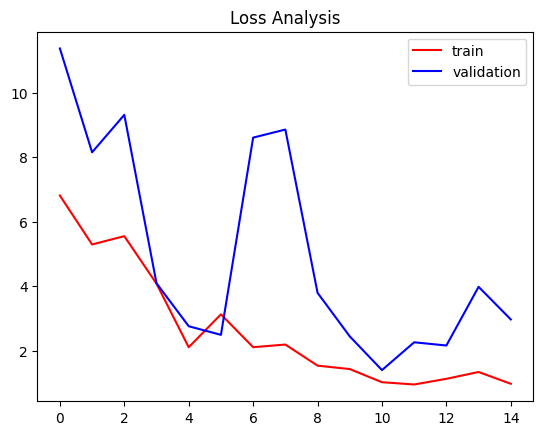

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.title("Loss Analysis")
plt.show()

array([[[238, 234, 229],
        [243, 239, 234],
        [251, 247, 242],
        ...,
        [187, 192, 183],
        [192, 197, 188],
        [192, 197, 188]],

       [[231, 225, 220],
        [235, 231, 226],
        [245, 241, 236],
        ...,
        [189, 194, 185],
        [195, 200, 191],
        [201, 206, 197]],

       [[223, 214, 210],
        [227, 221, 216],
        [238, 232, 227],
        ...,
        [191, 196, 187],
        [200, 205, 196],
        [199, 204, 195]],

       ...,

       [[ 87, 122, 125],
        [ 81, 117, 117],
        [ 84, 122, 122],
        ...,
        [129, 141, 113],
        [132, 143, 117],
        [127, 136, 115]],

       [[ 88, 122, 122],
        [ 81, 117, 117],
        [ 82, 120, 120],
        ...,
        [131, 143, 115],
        [135, 146, 120],
        [140, 150, 127]],

       [[ 76, 110, 110],
        [ 79, 115, 115],
        [ 81, 118, 116],
        ...,
        [133, 145, 117],
        [137, 148, 122],
        [134, 144, 121]]], dtype=uint8)
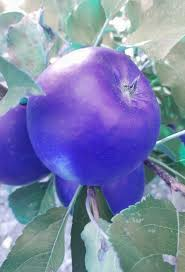

In [ ]:
import cv2

# টেস্ট ফোল্ডার থেকে নির্দিষ্ট ছবিটি লোড করা
test_img = cv2.imread("/content/test/apples/img_p1_111.jpeg")

# ছবির ডাইমেনশন বা অ্যারের আকৃতি দেখার জন্য
test_img

In [ ]:
import cv2

# ১. ইমেজ লোড, রিসাইজ এবং রিশেপ করা
test_img = cv2.imread("/content/test/apples/img_p1_127.jpeg")

test_img = cv2.resize(test_img, (256, 256))
test_input = test_img.reshape((1, 256, 256, 3))

# ২. মডেলের মাধ্যমে প্রেডিকশন করা এবং নরমালাইজড ইনপুট দেওয়া (আপনার স্ক্রিনশট অনুযায়ী)
result = model.predict(test_input / 255.0)
result  # আউটপুট ভ্যালু দেখার জন্য

# ৩. ফাইনাল আউটপুট কন্ডিশন (আপনার স্ক্রিনশট অনুযায়ী হুবহু লজিক)
if result[0][0] >= 0.5:
    prediction = 'Tomato'
    print(prediction)
else:
    prediction = 'Apple'
    print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Tomato


array([[[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       ...,

       [[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[242, 242, 242],
        [242, 242, 242],
        [242, 242, 242],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]]], dtype=uint8)
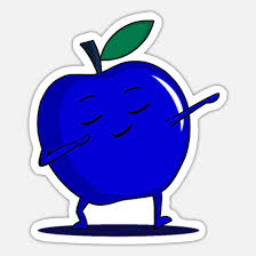

In [ ]:
test_img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create a sample DataFrame (replace with your actual DataFrame)
data = {'col1': [1, 2, 3], 'col2': ['A', 'B', 'C']}
df = pd.DataFrame(data)

# কোনো ডেটাফ্রেম বা ফাইল ড্রাইভের নির্দিষ্ট ফোল্ডারে সেভ করার নিয়ম
df.to_csv('/content/drive/MyDrive/my_data.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = '/content/train'
valid_path = '/content/test'

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (256, 256),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (256, 256),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 294 images belonging to 2 classes.
Found 97 images belonging to 2 classes.


### Saving Augmented Images

The `ImageDataGenerator` used in `flow_from_directory` performs data augmentation on-the-fly, meaning it generates augmented versions of your images during training without saving them permanently to disk. This is efficient for training.

If you need to inspect or save specific augmented images (e.g., for debugging or creating a pre-augmented dataset), you can use the `flow()` method along with the `save_to_dir` parameter.

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Create a directory to save augmented images
save_dir = '/content/augmented_images'
os.makedirs(save_dir, exist_ok=True)

# Define an ImageDataGenerator with augmentation parameters
sample_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load a sample image
sample_image_path = '/content/train/apples/img_p1_10.jpeg'
img = load_img(sample_image_path)

# Convert the image to an array and expand dimensions to create a batch of 1
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # Add a new dimension for batch size

# Generate and save 5 augmented images
i = 0
for batch in sample_datagen.flow(x, batch_size=1,
                                 save_to_dir=save_dir,
                                 save_prefix='aug',
                                 save_format='jpeg'):
    i += 1
    if i > 5: # Generate 5 augmented images
        break

print(f"5 augmented images saved to: {save_dir}")
print(f"You can view them by listing the contents of {save_dir}:")
!ls {save_dir}

5 augmented images saved to: /content/augmented_images
You can view them by listing the contents of /content/augmented_images:
aug_0_2799.jpeg  aug_0_4729.jpeg  aug_0_5369.jpeg
aug_0_4665.jpeg  aug_0_523.jpeg   aug_0_6264.jpeg


In [ ]:
# Re-compile the model before fitting again
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    training_set,
    validation_data=test_set,
    epochs=20,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7143 - loss: 1.6895 - val_accuracy: 0.4433 - val_loss: 6.0661
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step - accuracy: 0.7381 - loss: 0.9865 - val_accuracy: 0.4433 - val_loss: 4.3976
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 668ms/step - accuracy: 0.7143 - loss: 1.2096 - val_accuracy: 0.4124 - val_loss: 1.3406
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 419ms/step - accuracy: 0.7143 - loss: 0.6793 - val_accuracy: 0.5567 - val_loss: 7.5316
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 461ms/step - accuracy: 0.6939 - loss: 1.2120 - val_accuracy: 0.5567 - val_loss: 10.9226
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 536ms/step - accuracy: 0.6871 - loss: 0.7267 - val_accuracy: 0.5567 - val_loss: 14.1065
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 418ms/step - accuracy: 0.7313 - loss: 0.7219 - val_accuracy: 0.4742 - val_loss: 2.5316
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - accuracy: 0.7109 - loss: 0.6132 - val_accuracy: 0.

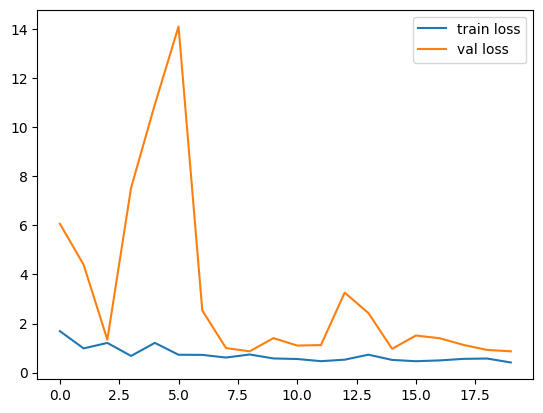

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.6392 - loss: 0.8667


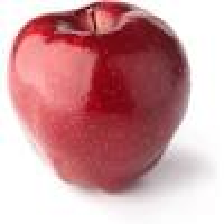

In [ ]:
model.evaluate(test_set)

model.save('model.h5')

from tensorflow.keras.models import load_model
model = load_model("model.h5")

from tensorflow.keras.preprocessing import image
img=image.load_img('/content/train/apples/img_p1_10.jpeg',target_size=(224,224))

img

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

x=image.img_to_array(img)
x=x/255

x=np.expand_dims(x,axis=0)

print(x.shape)

(1, 224, 224, 3)


In [ ]:
result[0][0]

np.float32(1.0)

In [ ]:
if result[0][0] >= 0.5:
    prediction = 'Tomato'
    print(prediction)
else:
    prediction = 'Apple'
    print(prediction)

Tomato


In [2]:
print("Hi ! I am Mahibullah")

Hi ! I am Mahibullah


In [3]:
!PWD


/bin/bash: line 1: PWD: command not found


In [4]:
!pwd

/content


In [5]:
ls

sample_data/
